# Sleep Health and Lifestyle Analysis: Predicting Sleep Disorders
**Author:** Kacper Andrzejewki | **Date:** March 2026

## 📌 Project Overview
The goal of this project is to analyze the relationship between lifestyle factors (e.g., physical activity, stress levels, BMI, blood pressure) and sleep health. By leveraging Machine Learning classification algorithms, we aim to predict the presence of sleep disorders, specifically **Insomnia** and **Sleep Apnea**.

**Key Objectives:**
1. Clean the dataset and perform feature engineering (e.g., splitting blood pressure into Systolic and Diastolic).
2. Select the most relevant features using correlation thresholds.
3. Build, evaluate, and compare multiple Machine Learning models.
4. Extract feature importances to understand the key lifestyle drivers behind sleep disorders.

## Uploading dataset


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('Sleep_health_and_lifestyle_dataset.csv')

## 1. Data Cleaning and Feature Engineering
In this section, we load the raw data and prepare it for modeling.
- **Dropping Irrelevant Features:** The `Person ID` column is removed as it holds no predictive value and could introduce noise,
- **Splitting Blood Pressure: ** The `Blood Pressure` column is removed due to splitting it into 2 new columns: `Systolic BP` and ` Diastolic BP`,
- **Handling Categorical Data:** We use One-Hot Encoding (`get_dummies`) to transform categorical variables (like Occupation and BMI Category) into a machine-readable numerical format (also target value - `Sleep Disorder` by mapping).

In [ ]:
df.head(15)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,140/90,85,3000,Insomnia
6,7,Male,29,Teacher,6.3,6,40,7,Obese,140/90,82,3500,Insomnia
7,8,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
8,9,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN
9,10,Male,29,Doctor,7.8,7,75,6,Normal,120/80,70,8000,NaN


In [ ]:
df[['Systolic BP', 'Diastolic BP']] = df['Blood Pressure'].str.split('/', expand=True).astype(int)
df = df.drop(['Blood Pressure'], axis=1)

df.head(15)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,NaN,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,NaN,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,85,3000,Insomnia,140,90
6,7,Male,29,Teacher,6.3,6,40,7,Obese,82,3500,Insomnia,140,90
7,8,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,NaN,120,80
8,9,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,NaN,120,80
9,10,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,NaN,120,80


In [ ]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Systolic BP,Diastolic BP
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920,128.553476,84.649733
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679,7.748118,6.161611
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000,115.000000,75.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000,125.000000,80.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000,130.000000,85.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000,135.000000,90.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000,142.000000,95.000000


In [ ]:
df.shape

(374, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Heart Rate               374 non-null    int64  
 10  Daily Steps              374 non-null    int64  
 11  Sleep Disorder           155 non-null    object 
 12  Systolic BP              374 non-null    int64  
 13  Diastolic BP             374 non-null    int64  
dtypes: float64(1), int64(9), o

In [ ]:
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Heart Rate,0


In [ ]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('No sleep disorder')

df.head(15)

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,No sleep disorder,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No sleep disorder,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,No sleep disorder,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,Sleep Apnea,140,90
5,6,Male,28,Software Engineer,5.9,4,30,8,Obese,85,3000,Insomnia,140,90
6,7,Male,29,Teacher,6.3,6,40,7,Obese,82,3500,Insomnia,140,90
7,8,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,No sleep disorder,120,80
8,9,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,No sleep disorder,120,80
9,10,Male,29,Doctor,7.8,7,75,6,Normal,70,8000,No sleep disorder,120,80


In [ ]:
df.isnull().sum()

,0
Person ID,0
Gender,0
Age,0
Occupation,0
Sleep Duration,0
Quality of Sleep,0
Physical Activity Level,0
Stress Level,0
BMI Category,0
Heart Rate,0


In [ ]:
mapping = {'No sleep disorder': 0, 'Sleep Apnea': 1, 'Insomnia': 2}
df['Sleep Disorder'] = df['Sleep Disorder'].map(mapping)

df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,77,4200,0,126,83
1,2,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,0,125,80
2,3,Male,28,Doctor,6.2,6,60,8,Normal,75,10000,0,125,80
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,1,140,90
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,85,3000,1,140,90


In [ ]:
encode_cols = ['Gender', 'Occupation', 'BMI Category']

df2 = pd.get_dummies(df, columns=encode_cols, drop_first=True, dtype=int)
#df2.columns

In [ ]:
df2 = df2.drop(['Person ID'], axis=1)
df2.head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps,Sleep Disorder,Systolic BP,Diastolic BP,...,Occupation_Manager,Occupation_Nurse,Occupation_Sales Representative,Occupation_Salesperson,Occupation_Scientist,Occupation_Software Engineer,Occupation_Teacher,BMI Category_Normal Weight,BMI Category_Obese,BMI Category_Overweight
0,27,6.1,6,42,6,77,4200,0,126,83,...,0,0,0,0,0,1,0,0,0,1
1,28,6.2,6,60,8,75,10000,0,125,80,...,0,0,0,0,0,0,0,0,0,0
2,28,6.2,6,60,8,75,10000,0,125,80,...,0,0,0,0,0,0,0,0,0,0
3,28,5.9,4,30,8,85,3000,1,140,90,...,0,0,1,0,0,0,0,0,1,0
4,28,5.9,4,30,8,85,3000,1,140,90,...,0,0,1,0,0,0,0,0,1,0


## 2. Feature Selection (Dimensionality Reduction)
To prevent the models from learning noise and to keep the architecture efficient, we apply a feature selection step based on Pearson correlation.
We calculate the absolute correlation of all features against our target variable (`Sleep Disorder`). We apply a **threshold of 0.15**, meaning any feature with a correlation lower than 15% is dropped.

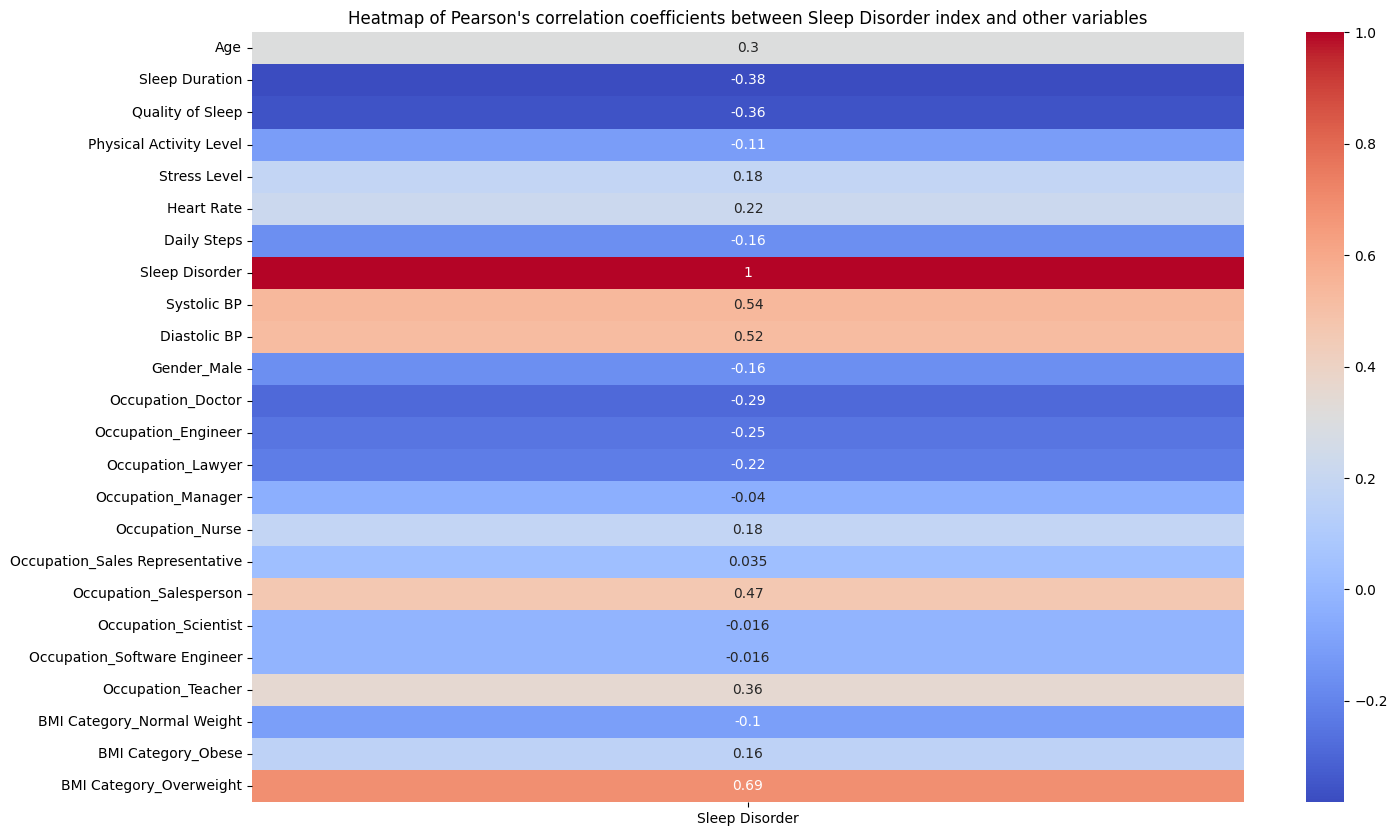

In [ ]:
matrix_cor = df2.corr()
fig, ax = plt.subplots(figsize=(16,10))
sns.heatmap(matrix_cor[['Sleep Disorder']], annot=True, cmap='coolwarm', ax=ax)
plt.title("Heatmap of Pearson's correlation coefficients between Sleep Disorder index and other variables")
plt.show()

## 3. Data Splitting and Feature Scaling
Before training, we split our dataset into training (80%) and testing (20%) sets. We use `stratify=y` to maintain the original proportion of target classes in both sets, which is crucial for medical datasets to avoid class imbalance issues in the test set.

Next, we apply `StandardScaler`. While tree-based models (Random Forest, XGBoost) are invariant to feature scaling, distance-based models (like k-NN) and linear/margin-based models (like Logistic Regression and SVM) strictly require normalized data (mean = 0, variance = 1) to perform correctly and converge efficiently. *Note: Scaling is applied after the split to prevent data leakage.*

In [ ]:
corrs = df2.corr()['Sleep Disorder'].abs().sort_values(ascending=False)

final_cols = corrs[corrs>0.15].index

X = df2[final_cols].drop(['Sleep Disorder'], axis=1)
y = df2['Sleep Disorder']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=50, stratify=y, test_size=0.2)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 4. Model Benchmarking
We are dealing with a multi-class classification problem with three distinct classes: `0: None`, `1: Sleep Apnea`, `2: Insomnia`.
We will train and evaluate a diverse set of five algorithms:
1. **Logistic Regression** (Baseline / Linear approach)
2. **k-Nearest Neighbors** (Instance-based learning)
3. **Support Vector Machine - RBF** (Margin-based classifier)
4. **Random Forest** (Bagging ensemble)
5. **XGBoost** (Boosting ensemble)

We evaluate them based on **Precision, Recall, and F1-Score** to see which model best handles the trade-off between false positives and false negatives.

### Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(multi_class='multinomial', max_iter=1000)
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)

print("Classification report for Logisitic Regression:")
print("\n")
print(classification_report(y_test, lr_pred))

Classification report for Logisitic Regression:


              precision    recall  f1-score   support

           0       0.98      0.95      0.97        44
           1       0.93      0.88      0.90        16
           2       0.82      0.93      0.88        15

    accuracy                           0.93        75
   macro avg       0.91      0.92      0.91        75
weighted avg       0.94      0.93      0.93        75



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


### kNN model

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
knn_pred = knn.predict(X_test_scaled)

print("Classification report for kNN:")
print("\n")
print(classification_report(y_test, knn_pred))

Classification report for Logisitic Regression:


              precision    recall  f1-score   support

           0       0.98      0.95      0.97        44
           1       0.88      0.94      0.91        16
           2       0.87      0.87      0.87        15

    accuracy                           0.93        75
   macro avg       0.91      0.92      0.91        75
weighted avg       0.93      0.93      0.93        75



### Random Forest Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)

print("Classification report for Random Forest:")
print("\n")
print(classification_report(y_test, rf_pred))

Classification report for Random Forest:


              precision    recall  f1-score   support

           0       0.98      0.98      0.98        44
           1       0.94      0.94      0.94        16
           2       0.93      0.93      0.93        15

    accuracy                           0.96        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.96      0.96      0.96        75



### SVM model

In [ ]:
from sklearn.svm import SVC

svc = SVC(kernel='rbf', probability=True)
svc.fit(X_train_scaled, y_train)
svc_pred = svc.predict(X_test_scaled)

print("Classification report for SVC:")
print("\n")
print(classification_report(y_test, svc_pred))

Classification report for SVC:


              precision    recall  f1-score   support

           0       0.98      0.95      0.97        44
           1       0.88      0.94      0.91        16
           2       0.87      0.87      0.87        15

    accuracy                           0.93        75
   macro avg       0.91      0.92      0.91        75
weighted avg       0.93      0.93      0.93        75



### XGBoost model

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1)
xgb.fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)

print("Classification report for XGBoost:")
print("\n")
print(classification_report(y_test, xgb_pred))

Classification report for XGBoost:


              precision    recall  f1-score   support

           0       0.98      0.98      0.98        44
           1       0.94      0.94      0.94        16
           2       0.93      0.93      0.93        15

    accuracy                           0.96        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.96      0.96      0.96        75



## 5. Model Interpretation: Feature Importance
The **Random Forest** model emerged as one of the top performers (yielding ~96% accuracy). To ensure the model's decisions are medically logical and not based on data artifacts, we extract its **Feature Importances**. This allows us to "open the black box" and see exactly which lifestyle factors carry the most weight in predicting sleep disorders.

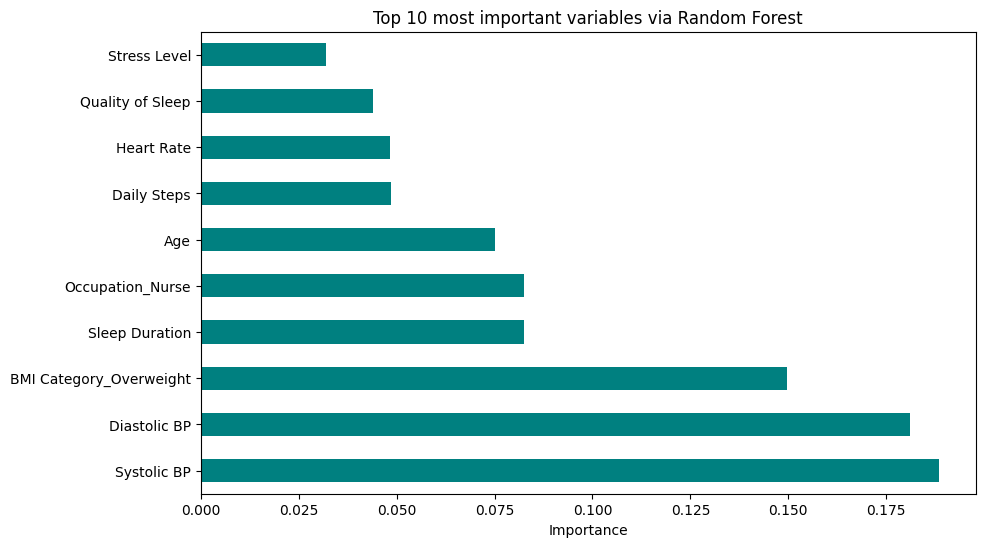

In [ ]:
best_model = rf

feat_importances = pd.Series(best_model.feature_importances_, index=X.columns)

plt.figure(figsize=(10,6))
feat_importances.nlargest(10).plot(kind='barh', color='teal')
plt.title('Top 10 most important variables via Random Forest')
plt.xlabel('Importance')
plt.show()

## 6. Error Analysis: Confusion Matrix
High accuracy can sometimes be misleading. To truly understand our Random Forest model's performance, we analyze its **Confusion Matrix** on the unseen test data. This matrix helps us identify exactly where the model gets confused—for instance, ensuring it does not dangerously misclassify severe 'Sleep Apnea' as 'No sleep disorder'.

<Figure size 800x600 with 0 Axes>

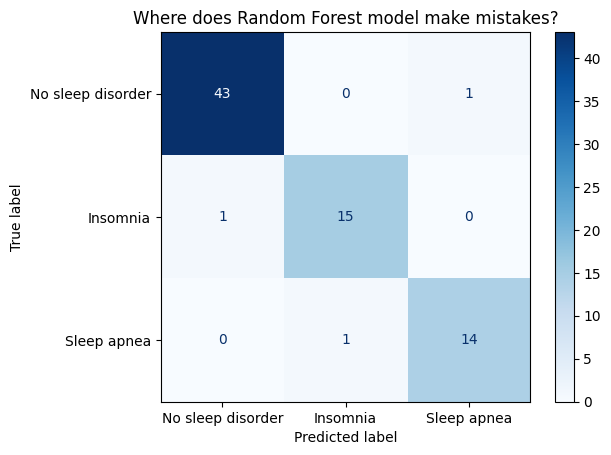

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No sleep disorder', 'Insomnia', 'Sleep apnea'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Where does Random Forest model make mistakes?')
plt.show()

## 💡 Final Conclusions
1. **Strong Predictability:** Lifestyle metrics are excellent indicators of sleep health. Our best model (**Random Forest**) achieved an outstanding **96% accuracy**, making only 3 mistakes out of 75 unseen test cases.
2. **Key Risk Factors:** The Feature Importance analysis revealed that **Blood Pressure (Systolic & Diastolic)** and **BMI (Overweight category)** are the most critical predictors of sleep disorders in this dataset.
3. **Clinical Safety:** The model exhibits high Recall for Sleep Apnea, meaning it is very effective at catching the most severe condition, prioritizing patient safety over minor false-positive alarms.

*Project completed successfully. The dataset confirms that taking care of cardiovascular health and maintaining a healthy weight are closely tied to a good night's sleep.*